# 🏥 Hospital Appointment No-Show Prediction & Analysis


## 📋 Project Overview
This notebook analyzes over 110,000 medical appointments to identify key drivers behind patient "no-shows". By integrating data cleaning, feature engineering, and advanced visualization, we provide actionable insights to improve hospital operational efficiency.

### ⚙️ Step 1: Environment Setup & Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load Dataset 
try:
    # Using 'latin1' to handle potential encoding issues from the CSV
    df = pd.read_csv('apollo_raw.csv', encoding='latin1')
    print(f"✅ Success: Loaded {df.shape[0]} records.")
except FileNotFoundError:
    print("❌ Error: 'apollo_raw.csv' not found. Please upload the dataset.")

# --- THE FIX: FORCED DATETIME CONVERSION ---
# We force conversion and "coerce" errors to ensure the columns become datetimelike
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce')

# Verify the types - they MUST say datetime64[ns]
print("\nVerifying Column Types:")
print(df[['ScheduledDay', 'AppointmentDay']].dtypes)

✅ Success: Loaded 110527 records.

Verifying Column Types:
ScheduledDay      datetime64[us]
AppointmentDay    datetime64[us]
dtype: object


### 🧹 Step 2: Forensic Audit & Data Cleaning

In [13]:
# 1. Audit and remove rows where dates failed to convert (NaT)
df = df.dropna(subset=['ScheduledDay', 'AppointmentDay'])

# 2. Negative Age Audit
negative_ages = df[df['Age'] < 0].shape[0]

# 3. Date Corruption Audit (Appointment before Scheduling)
corrupted_dates = df[df['AppointmentDay'].dt.date < df['ScheduledDay'].dt.date].shape[0]

print(f"--- Data Quality Audit ---\n")
print(f"Total Rows: {len(df)}")
print(f"Negative Age Errors: {negative_ages}")
print(f"Date Mismatch Errors: {corrupted_dates}")

# Cleaning: Apply Exclusion Rules
# Replicates the WHERE clause: age >= 0 AND appointment_day >= scheduled_day
df_clean = df[(df['Age'] >= 0) & (df['AppointmentDay'].dt.date >= df['ScheduledDay'].dt.date)].copy()
print(f"\nFinal Cleaned Rows for Analysis: {len(df_clean)}")

--- Data Quality Audit ---

Total Rows: 110526
Negative Age Errors: 0
Date Mismatch Errors: 203

Final Cleaned Rows for Analysis: 110323


### 🏗️ Step 3: Feature Engineering

In [14]:
# Convert Text to Numeric Flag (No-Show: Yes = 1, No = 0)
df_clean['NoShowFlag'] = df_clean['No-show'].apply(lambda x: 1 if x == 'Yes' else 0)

# --- THE FIX: ROBUST CALCULATION ---
# normalize() ensures we compare only dates, then we subtract and extract the integer days
df_clean['WaitDays'] = (df_clean['AppointmentDay'].dt.normalize() - df_clean['ScheduledDay'].dt.normalize()).dt.days

# Wait Buckets (Used for Heatmap)
def get_wait_bucket(days):
    if days == 0: return '0 - Same Day'
    if 1 <= days <= 7: return '1-7 Days'
    if 8 <= days <= 30: return '8-30 Days'
    return '30+ Days'

df_clean['WaitBucket'] = df_clean['WaitDays'].apply(get_wait_bucket)

# Age Demographic Groups
def get_age_group(age):
    if age <= 17: return 'Child (0-17)'
    if age <= 35: return 'Young Adult (18-35)'
    if age <= 60: return 'Adult (36-60)'
    return 'Senior (60+)'

df_clean['AgeGroup'] = df_clean['Age'].apply(get_age_group)

print("✅ Feature Engineering Complete.")

✅ Feature Engineering Complete.


### 📊 Step 4: Visual Analysis & Insights

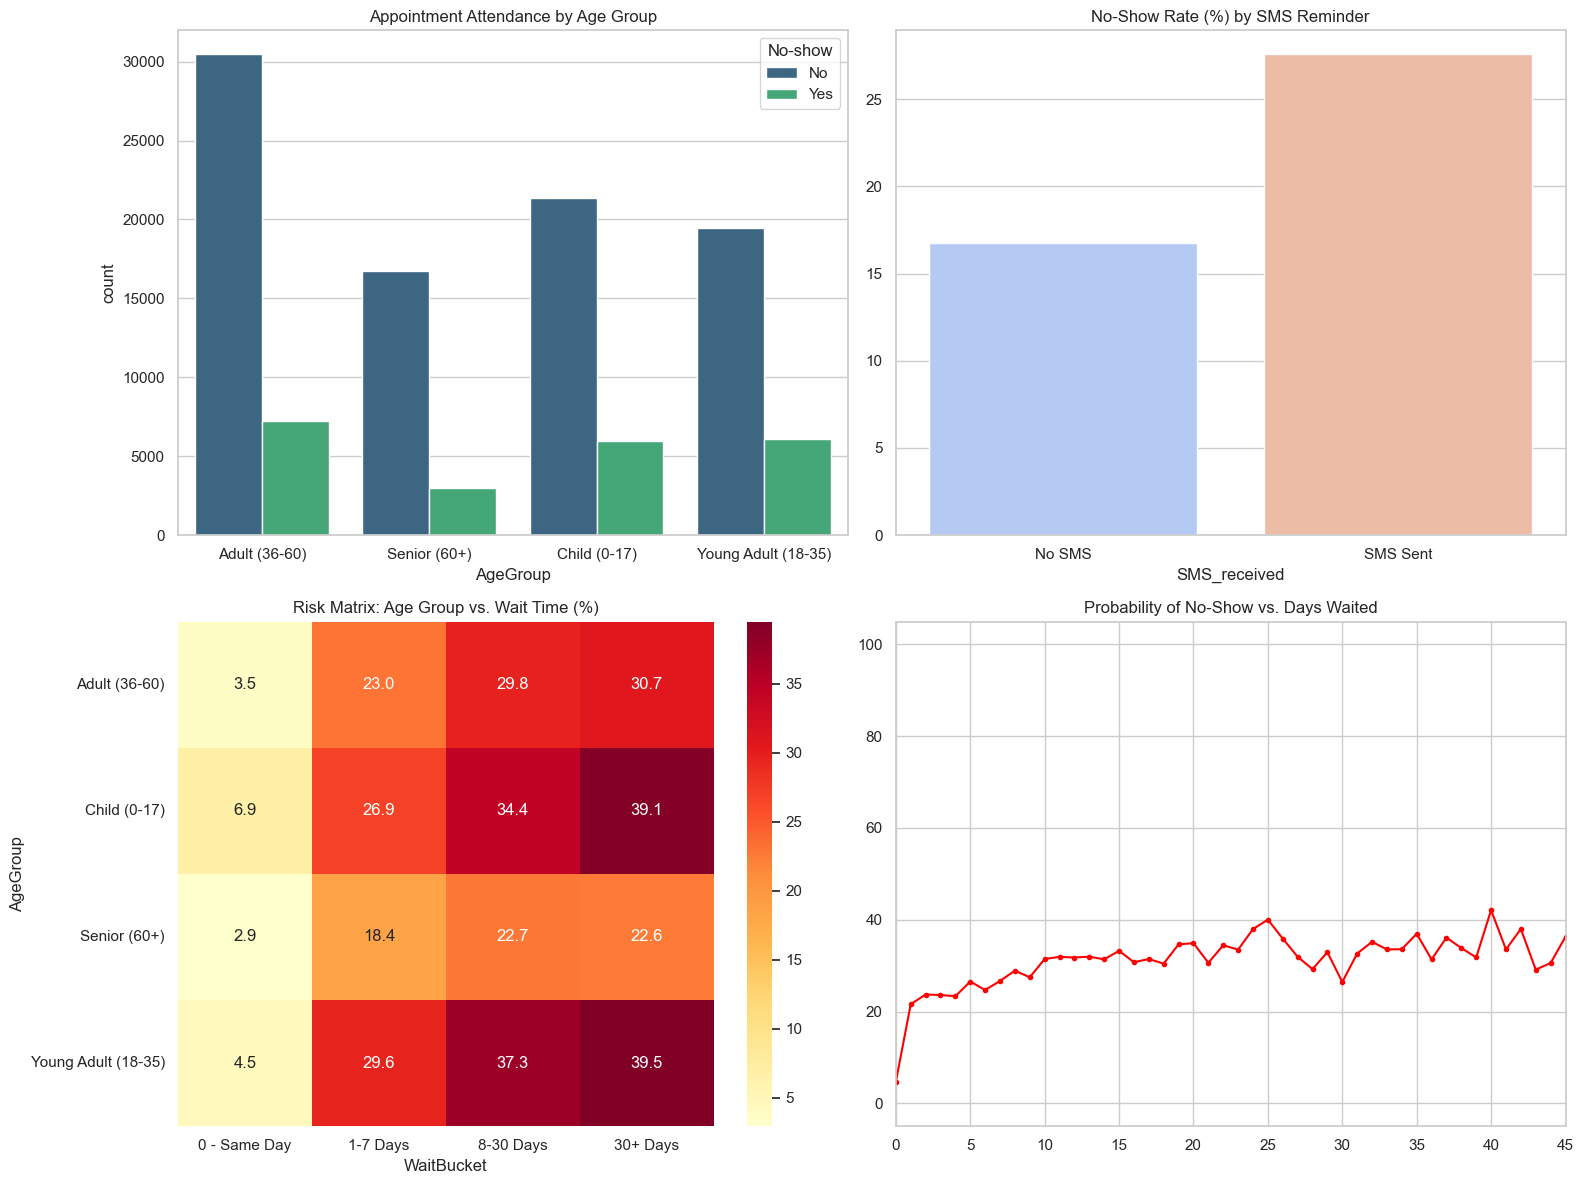

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Visual 1: Age Group Distribution
sns.countplot(data=df_clean, x='AgeGroup', hue='No-show', palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Appointment Attendance by Age Group')

# Visual 2: SMS Effectiveness
sms_rate = df_clean.groupby('SMS_received')['NoShowFlag'].mean() * 100
sns.barplot(x=sms_rate.index, y=sms_rate.values, palette='coolwarm', ax=axes[0,1])
axes[0,1].set_title('No-Show Rate (%) by SMS Reminder')
axes[0,1].set_xticklabels(['No SMS', 'SMS Sent'])

# Visual 3: Risk Heatmap
pivot_table = df_clean.pivot_table(index='AgeGroup', columns='WaitBucket', values='NoShowFlag', aggfunc='mean') * 100
ordered_buckets = ['0 - Same Day', '1-7 Days', '8-30 Days', '30+ Days']
sns.heatmap(pivot_table[ordered_buckets], annot=True, cmap='YlOrRd', fmt=".1f", ax=axes[1,0])
axes[1,0].set_title('Risk Matrix: Age Group vs. Wait Time (%)')

# Visual 4: Wait Time Impact
wait_trend = df_clean.groupby('WaitDays')['NoShowFlag'].mean() * 100
axes[1,1].plot(wait_trend.index, wait_trend.values, color='red', marker='o', markersize=3)
axes[1,1].set_xlim(0, 45)
axes[1,1].set_title('Probability of No-Show vs. Days Waited')

plt.tight_layout()
plt.show()